In [1]:
# ENVIRONMENT SETUP
import sys, subprocess, importlib.util

required = [
    "numpy", "pandas", "matplotlib", "scikit-learn", "xgboost", "shap"
]

missing = [pkg for pkg in required if importlib.util.find_spec(pkg.replace("scikit-learn", "sklearn")) is None]
if missing:
    print("Missing packages:", missing)
else:
    print("All main packages are available.")

All main packages are available.


In [2]:
# IMPORTS
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)

# Seasonal Snowfall Prediction in the European Alps
## A Machine Learning Investigation Using Climate Reanalysis and Topographic Data

---

Seasonal snowfall is a mountain-climate problem where **atmospheric variables** and **topography** interact.  
This notebook studies whether **September–November temperature and precipitation**, together with **elevation**, can predict **winter snowfall** in the European Alps.

> Research question: **To what extent can winter snowfall in the European Alps be predicted using autumn climate conditions and geographic characteristics?**

---

## 0. Executive Summary

This project builds and evaluates a supervised machine learning workflow for predicting winter snowfall across Alpine grid cells. The predictors are autumn climate variables from ERA5-Land-style reanalysis data and static topographic elevation. The target variable is seasonal winter snowfall.

The notebook follows a technical-report style:

1. formulate the real-world and mathematical problem;
2. validate and explore the data;
3. engineer physically meaningful features;
4. compare interpretable baseline models with non-linear machine learning models;
5. diagnose model behavior and explain feature effects.

The central hypothesis is that **winter snowfall is controlled by a nonlinear combination of autumn temperature, autumn precipitation, and elevation**. Linear models provide a transparent baseline, while Random Forest and XGBoost are tested because tree ensembles can model interactions and nonlinear thresholds.

---
## Section 1 — Introduction


Seasonal snowfall affects freshwater storage, river discharge, hydropower planning, avalanche risk, ecosystems, and winter tourism. The European Alps are especially sensitive because precipitation phase depends strongly on temperature: small warming can shift precipitation from snow to rain near the freezing point.

### 1.1 Research Question

**To what extent can winter snowfall in the European Alps be predicted using autumn climate conditions and geographic characteristics?**

More specifically:

- Can September–November temperature predict winter snowfall?
- Can autumn precipitation indicate future snow accumulation?
- How important is elevation?
- Which variables contribute most to snowfall variability?
- Can machine learning outperform traditional statistical models?

### 1.2 Objectives

1. Merge climate and elevation data for Alpine grid cells.
2. Validate missingness, plausible ranges, and physical consistency.
3. Build baseline statistical models: Linear Regression, Ridge, and Lasso.
4. Build nonlinear machine learning models: Random Forest and XGBoost.
5. Compare models using MAE, RMSE, and $R^2$.
6. Interpret model decisions using feature importance and SHAP values.

---
## Section 2 — Literature Review

### 2.1 Snowfall Formation

Snowfall forms when atmospheric moisture condenses and freezes into ice crystals, and when the vertical temperature profile allows solid precipitation to reach the surface. Near-surface air temperature is therefore a strong control on whether precipitation falls as rain or snow. In this project, monthly autumn temperature variables are used as predictors because they provide information about seasonal thermal state before winter.

### 2.2 Orographic Precipitation

Mountains force air masses to rise. Rising air cools, reaches saturation, and can produce enhanced precipitation on windward slopes. This process is known as **orographic precipitation**. Studies of mountain precipitation emphasize that terrain lifting can favor condensation and cloud formation, creating strong spatial gradients in precipitation across mountain ranges. Source: Napoli et al. (2019), *Variability of orographic enhancement of precipitation in the Alpine region*, https://pmc.ncbi.nlm.nih.gov/articles/PMC6746858/

### 2.3 Elevation Effects

Elevation affects snowfall through temperature lapse rates and exposure to orographic precipitation. ERA5-Land itself applies an elevation correction to the thermodynamic near-surface state, which shows why elevation is physically important for land-surface climate analysis. Source: Muñoz-Sabater et al. (2021), *ERA5-Land: a state-of-the-art global reanalysis dataset for land applications*, https://essd.copernicus.org/articles/13/4349/2021/

### 2.4 Machine Learning in Climate Science

Machine learning is increasingly used in weather and climate because it can model nonlinear relationships and interactions that are difficult to represent with simple linear equations. Tree-based ensembles are useful for tabular environmental data because they can learn thresholds and variable interactions without requiring explicit polynomial terms.

Useful method references:

- Random Forest Regressor, scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html
- Ridge regression, scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html
- Lasso regression, scikit-learn: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html
- XGBoost documentation: https://xgboost.readthedocs.io/en/stable/
- SHAP documentation: https://shap.readthedocs.io/en/latest/

---
## Section 3 — Data Collection

### 3.1 ERA5-Land

The climate dataset represents ERA5-Land-style reanalysis variables over the European Alps:

| Variable | Meaning | Role |
|---|---:|---|
| `t2m` / monthly temperature | 2-meter air temperature | predictor |
| `tp` / monthly precipitation | total precipitation | predictor |
| `sf` / winter snowfall | snowfall | target |

ERA5-Land is produced by ECMWF under the Copernicus Climate Change Service. ECMWF describes ERA5-Land as a high-resolution land reanalysis dataset with hourly surface-variable information and approximately 9 km grid spacing. Source: https://www.ecmwf.int/en/era5-land

The Copernicus Climate Data Store describes ERA5-Land as a dataset providing a consistent view of land-variable evolution over multiple decades. Source: https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land

### 3.2 Elevation Dataset

The elevation dataset is a DEM-derived table containing latitude, longitude, and elevation in meters for each grid cell.

### 3.3 Data Processing Pipeline

The data pipeline is:

1. read climate and elevation CSV files;
2. merge by latitude and longitude;
3. validate values;
4. engineer autumn and topographic features;
5. split by year to avoid temporal leakage;
6. train baseline and machine learning models.

In [3]:
# ── LOAD DATA ─────────────────────────────────────────────────────────────────


climate_path = "../datasets/alps_snowfall_ml_dataset.csv"
elevation_path = "../datasets/alps_elevation.csv"

climate = pd.read_csv(climate_path)
elevation = pd.read_csv(elevation_path)

print("Climate shape:", climate.shape)
print("Elevation shape:", elevation.shape)
display(climate.head())
display(elevation.head())

Climate shape: (147186, 10)
Elevation shape: (5661, 3)


,lat,lon,sep_temp,oct_temp,nov_temp,sep_precip,oct_precip,nov_precip,winter_snowfall,year
0,48.0,5.0,13.720734,9.956451,6.689029,0.093543,0.118970,0.161477,0.022422,2000
1,48.0,5.1,13.533885,9.793838,6.473730,0.096865,0.119708,0.168315,0.023954,2000
2,48.0,5.2,13.359926,9.584475,6.221841,0.098739,0.120086,0.173524,0.024710,2000
3,48.0,5.3,13.320474,9.519834,6.112857,0.096361,0.119496,0.174590,0.023715,2000
4,48.0,5.4,13.381606,9.522227,6.059016,0.092295,0.118310,0.173335,0.021996,2000


,lat,lon,elevation
0,48.0,5.0,312.920105
1,48.0,5.1,353.805573
2,48.0,5.2,402.360992
3,48.0,5.3,380.785126
4,48.0,5.4,462.431274


In [4]:
# ── MERGE CLIMATE + ELEVATION ────────────────────────────────────────────────
for df in [climate, elevation]:
    df["lat_key"] = df["lat"].round(1).astype(str)
    df["lon_key"] = df["lon"].round(1).astype(str)

data = climate.merge(
    elevation[["lat_key", "lon_key", "elevation"]],
    on=["lat_key", "lon_key"],
    how="left"
).drop(columns=["lat_key", "lon_key"])

print("Merged shape:", data.shape)
print("Missing elevation rows:", data["elevation"].isna().sum())
display(data.head())

Merged shape: (147186, 11)
Missing elevation rows: 26858


,lat,lon,sep_temp,oct_temp,nov_temp,sep_precip,oct_precip,nov_precip,winter_snowfall,year,elevation
0,48.0,5.0,13.720734,9.956451,6.689029,0.093543,0.118970,0.161477,0.022422,2000,312.920105
1,48.0,5.1,13.533885,9.793838,6.473730,0.096865,0.119708,0.168315,0.023954,2000,353.805573
2,48.0,5.2,13.359926,9.584475,6.221841,0.098739,0.120086,0.173524,0.024710,2000,402.360992
3,48.0,5.3,13.320474,9.519834,6.112857,0.096361,0.119496,0.174590,0.023715,2000,380.785126
4,48.0,5.4,13.381606,9.522227,6.059016,0.092295,0.118310,0.173335,0.021996,2000,462.431274


In [5]:
print(elevation["elevation"].isna().sum())
print(elevation[elevation["elevation"].isna()].head())

1033
       lat   lon  elevation lat_key lon_key
2634  45.7  13.1        NaN    45.7    13.1
2635  45.7  13.2        NaN    45.7    13.2
2636  45.7  13.3        NaN    45.7    13.3
2637  45.7  13.4        NaN    45.7    13.4
2638  45.7  13.5        NaN    45.7    13.5


---
The elevation dataset contained **1033 grid cells with missing DEM values**. Since these grid cells could not provide valid topographic information, they were removed after merging. This removed 26,858 rows, corresponding to repeated yearly observations for the same missing locations.

---
## Section 4 — Data Validation

Validation matters because machine learning models can produce accurate-looking results from physically impossible or corrupted data. Here we check:

1. missing values;
2. plausible ranges;
3. physical consistency between temperature, precipitation, elevation, and snowfall.

In [6]:
# ── 4.1 MISSING VALUES ───────────────────────────────────────────────────────
missing = data.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(data) * 100).round(3)
missing_report = pd.DataFrame({"missing_count": missing, "missing_percent": missing_pct})
display(missing_report)

# Basic rule: if a row is missing a target or elevation, it cannot be used in supervised learning.
data = data.dropna(subset=["winter_snowfall", "elevation"]).copy()

,missing_count,missing_percent
sep_temp,27508,18.689
oct_temp,27508,18.689
nov_temp,27508,18.689
elevation,26858,18.248
lat,0,0.000
lon,0,0.000
sep_precip,0,0.000
oct_precip,0,0.000
nov_precip,0,0.000
winter_snowfall,0,0.000


In [7]:
# ── 4.2 RANGE CHECKS ─────────────────────────────────────────────────────────
range_report = data.describe().T[["min", "mean", "max", "std"]]
display(range_report)

checks = {
    "negative_precipitation": (data[["sep_precip", "oct_precip", "nov_precip"]] < 0).sum().sum(),
    "negative_snowfall": (data["winter_snowfall"] < 0).sum(),
    "elevation_below_minus_500m": (data["elevation"] < -500).sum(),
    "elevation_above_5000m": (data["elevation"] > 5000).sum(),
}
checks

,min,mean,max,std
lat,43.000000,45.856806,48.000000,1.357543
lon,5.000000,10.232066,16.000000,3.197567
sep_temp,-4.436941,11.823158,22.992643,4.304702
oct_temp,-8.819291,8.000020,19.912125,4.279507
nov_temp,-12.252303,3.023112,15.417462,4.491403
sep_precip,0.000000,0.116104,0.574041,0.060809
oct_precip,0.000000,0.112697,0.877210,0.062974
nov_precip,0.000000,0.124981,0.771542,0.087951
winter_snowfall,0.000000,0.175281,1.001130,0.169806
year,2000.000000,2012.500000,2025.000000,7.500031


{'negative_precipitation': np.int64(0),
 'negative_snowfall': np.int64(0),
 'elevation_below_minus_500m': np.int64(0),
 'elevation_above_5000m': np.int64(0)}

In [8]:
# ── 4.3 PHYSICAL CONSISTENCY ─────────────────────────────────────────────────
# Snowfall should generally increase with elevation and decrease with warmer autumn temperatures,
# but noisy exceptions are expected because storms, wind direction, and regional circulation matter.

physical_summary = data[[
    "sep_temp", "oct_temp", "nov_temp",
    "sep_precip", "oct_precip", "nov_precip",
    "elevation", "winter_snowfall"
]].corr(numeric_only=True)[["winter_snowfall"]].sort_values("winter_snowfall", ascending=False)

display(physical_summary)

,winter_snowfall
winter_snowfall,1.000000
elevation,0.746102
sep_precip,0.229227
oct_precip,0.129123
nov_precip,0.079334
oct_temp,-0.771522
sep_temp,-0.803540
nov_temp,-0.817772


---
## Section 5 — Exploratory Data Analysis

EDA helps determine whether the target is skewed, whether elevation is well represented, and whether predictors show meaningful relationships with winter snowfall.

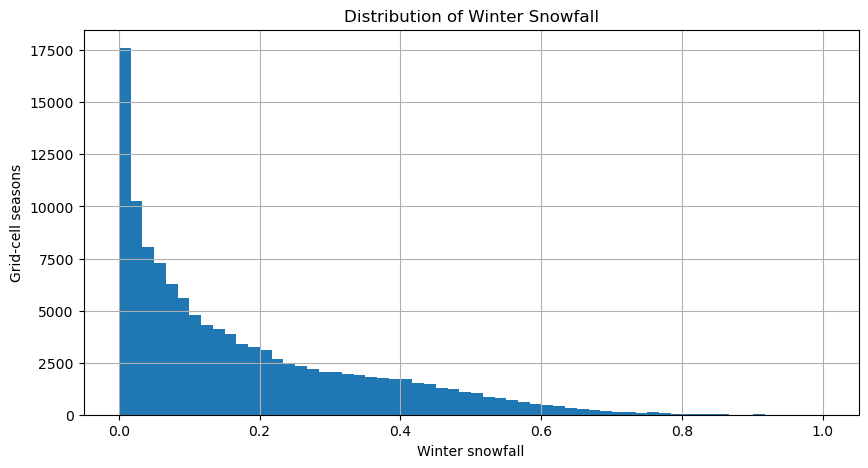

count    120328.000000
mean          0.175281
std           0.169806
min           0.000000
25%           0.037665
50%           0.117855
75%           0.273569
max           1.001130
Name: winter_snowfall, dtype: float64


In [9]:
#5.1 SNOWFALL DISTRIBUTION 
fig, ax = plt.subplots()
ax.hist(data["winter_snowfall"], bins=60)
ax.set_title("Distribution of Winter Snowfall")
ax.set_xlabel("Winter snowfall")
ax.set_ylabel("Grid-cell seasons")
plt.show()

print(data["winter_snowfall"].describe())

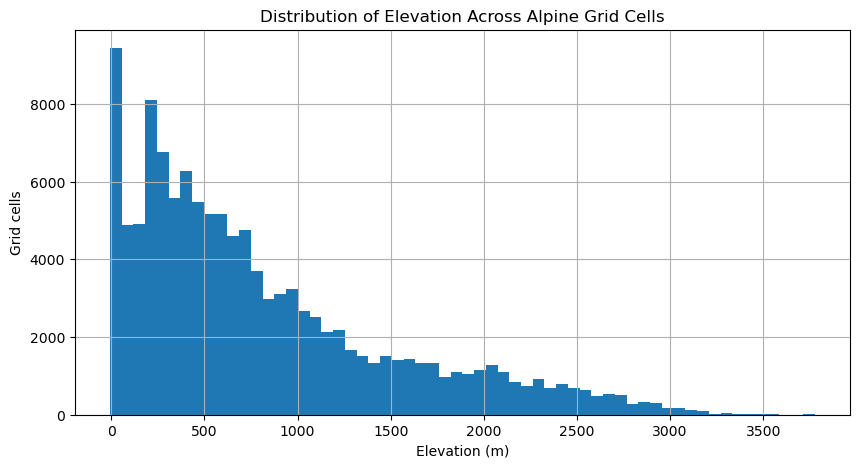

In [10]:
#5.2 ELEVATION DISTRIBUTION
fig, ax = plt.subplots()
ax.hist(data["elevation"], bins=60)
ax.set_title("Distribution of Elevation Across Alpine Grid Cells")
ax.set_xlabel("Elevation (m)")
ax.set_ylabel("Grid cells")
plt.show()

,sep_temp,oct_temp,nov_temp,sep_precip,oct_precip,nov_precip,elevation,winter_snowfall
sep_temp,1.000,0.906,0.918,-0.293,-0.036,-0.023,-0.830,-0.804
oct_temp,0.906,1.000,0.899,-0.173,-0.060,0.016,-0.808,-0.772
nov_temp,0.918,0.899,1.000,-0.205,-0.057,0.032,-0.826,-0.818
sep_precip,-0.293,-0.173,-0.205,1.000,0.204,0.067,0.161,0.229
oct_precip,-0.036,-0.060,-0.057,0.204,1.000,0.237,0.121,0.129
nov_precip,-0.023,0.016,0.032,0.067,0.237,1.000,0.066,0.079
elevation,-0.830,-0.808,-0.826,0.161,0.121,0.066,1.000,0.746
winter_snowfall,-0.804,-0.772,-0.818,0.229,0.129,0.079,0.746,1.000


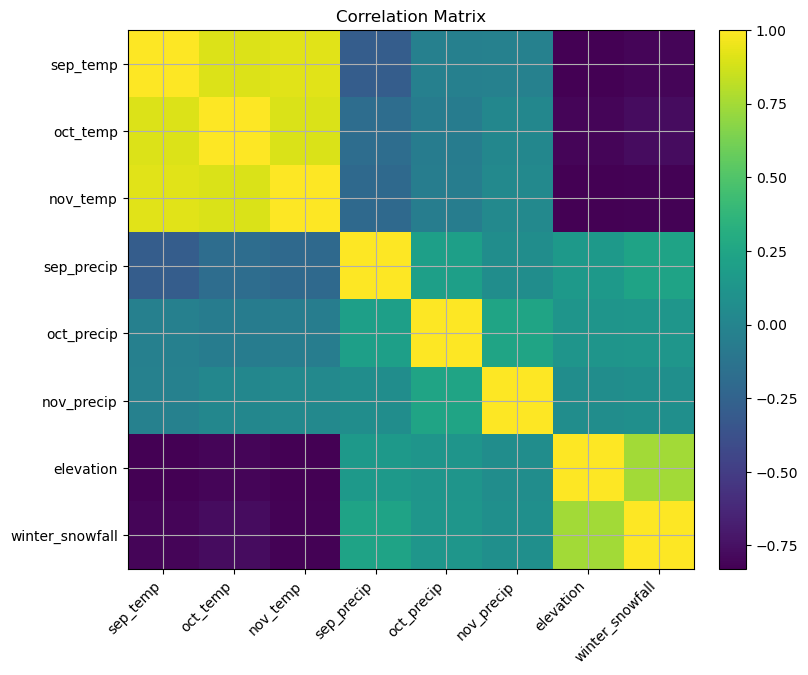

In [11]:
#5.3 CORRELATION ANALYSIS 
features_for_corr = [
    "sep_temp", "oct_temp", "nov_temp",
    "sep_precip", "oct_precip", "nov_precip",
    "elevation", "winter_snowfall"
]

corr = data[features_for_corr].corr(numeric_only=True)
display(corr.round(3))

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
ax.set_title("Correlation Matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

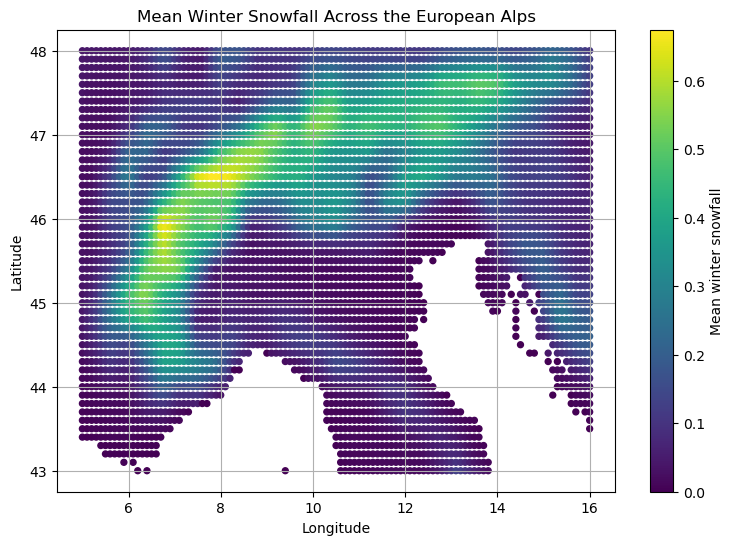

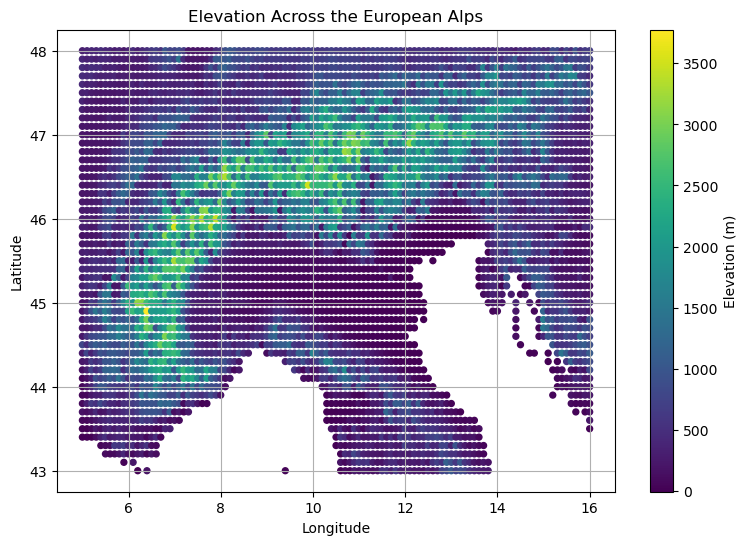

In [12]:
# 5.4 SPATIAL VISUALIZATION
# Average winter snowfall by grid cell over all years.
spatial = data.groupby(["lat", "lon"], as_index=False).agg(
    mean_snowfall=("winter_snowfall", "mean"),
    elevation=("elevation", "first")
)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(spatial["lon"], spatial["lat"], c=spatial["mean_snowfall"], s=18)
ax.set_title("Mean Winter Snowfall Across the European Alps")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.colorbar(sc, ax=ax, label="Mean winter snowfall")
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(spatial["lon"], spatial["lat"], c=spatial["elevation"], s=18)
ax.set_title("Elevation Across the European Alps")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.colorbar(sc, ax=ax, label="Elevation (m)")
plt.show()

---
## Section 6 — Hypothesis Development

### Main hypothesis

Winter snowfall can be predicted from autumn climate and elevation because snowfall is constrained by three linked mechanisms:

1. **Moisture supply**: autumn precipitation variables approximate seasonal wetness.
2. **Thermal state**: autumn temperature variables approximate whether the region is cold enough for snow.
3. **Topographic forcing**: elevation changes temperature and precipitation patterns.

### Mathematical prediction task

For each grid-cell year $i$, the supervised learning problem is:

$$
\hat{y}_i = f(x_i)
$$

where $y_i$ is winter snowfall and $x_i$ contains autumn temperature, precipitation, elevation, spatial coordinates, and engineered seasonal predictors.

The model is evaluated by comparing predictions $\hat{y}_i$ with observed snowfall $y_i$ using:

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

$$
RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

$$
R^2 = 1 - \frac{\sum_i(y_i - \hat{y}_i)^2}{\sum_i(y_i - \bar{y})^2}
$$

Metric reference: scikit-learn model evaluation documentation, https://scikit-learn.org/stable/modules/model_evaluation.html

---
## Section 7 — Feature Engineering

The raw variables are useful, but snowfall physics suggests additional predictors:

- `autumn_temp_mean`: overall pre-winter thermal state;
- `autumn_precip_total`: total moisture availability;
- `temp_drop_sep_to_nov`: seasonal cooling strength;
- `precip_temp_interaction`: wetness weighted by coldness;
- `elevation_x_precip`: interaction between moisture supply and topography;
- `elevation_band`: categorical topographic zone converted into dummy variables.

In [13]:
# ── FEATURE ENGINEERING ──────────────────────────────────────────────────────
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["autumn_temp_mean"] = out[["sep_temp", "oct_temp", "nov_temp"]].mean(axis=1)
    out["autumn_precip_total"] = out[["sep_precip", "oct_precip", "nov_precip"]].sum(axis=1)
    out["temp_drop_sep_to_nov"] = out["sep_temp"] - out["nov_temp"]
    out["precip_temp_interaction"] = out["autumn_precip_total"] * (-out["autumn_temp_mean"])
    out["elevation_x_precip"] = out["elevation"] * out["autumn_precip_total"]
    out["elevation_x_cold"] = out["elevation"] * (-out["autumn_temp_mean"])

    # Topographic bands are simple, interpretable terrain zones.
    out["elevation_band"] = pd.cut(
        out["elevation"],
        bins=[-np.inf, 500, 1000, 1500, 2000, np.inf],
        labels=["low", "foothill", "montane", "subalpine", "alpine"]
    )
    out = pd.get_dummies(out, columns=["elevation_band"], drop_first=True)
    return out

model_data = engineer_features(data)
print(model_data.shape)
display(model_data.head())

(120328, 21)


,lat,lon,sep_temp,oct_temp,nov_temp,sep_precip,oct_precip,nov_precip,winter_snowfall,year,elevation,autumn_temp_mean,autumn_precip_total,temp_drop_sep_to_nov,precip_temp_interaction,elevation_x_precip,elevation_x_cold,elevation_band_foothill,elevation_band_montane,elevation_band_subalpine,elevation_band_alpine
0,48.0,5.0,13.720734,9.956451,6.689029,0.093543,0.118970,0.161477,0.022422,2000,312.920105,10.122071,0.373991,7.031705,-3.785559,117.029150,-3167.399593,False,False,False,False
1,48.0,5.1,13.533885,9.793838,6.473730,0.096865,0.119708,0.168315,0.023954,2000,353.805573,9.933818,0.384888,7.060155,-3.823402,136.175353,-3514.640000,False,False,False,False
2,48.0,5.2,13.359926,9.584475,6.221841,0.098739,0.120086,0.173524,0.024710,2000,402.360992,9.722081,0.392349,7.138085,-3.814446,157.865814,-3911.786133,False,False,False,False
3,48.0,5.3,13.320474,9.519834,6.112857,0.096361,0.119496,0.174590,0.023715,2000,380.785126,9.651055,0.390447,7.207617,-3.768223,148.676330,-3674.978192,False,False,False,False
4,48.0,5.4,13.381606,9.522227,6.059016,0.092295,0.118310,0.173335,0.021996,2000,462.431274,9.654283,0.383940,7.322590,-3.706666,177.545894,-4464.442360,False,False,False,False


In [14]:
# ── TRAIN / TEST SPLIT BY YEAR ───────────────────────────────────────────────
# Temporal split avoids using future winters to predict past winters.
# We train on 2000–2020 and test on 2021–2025.

TARGET = "winter_snowfall"
base_features = [
    "lat", "lon", "year",
    "sep_temp", "oct_temp", "nov_temp",
    "sep_precip", "oct_precip", "nov_precip",
    "elevation", "autumn_temp_mean", "autumn_precip_total",
    "temp_drop_sep_to_nov", "precip_temp_interaction",
    "elevation_x_precip", "elevation_x_cold"
]
band_features = [c for c in model_data.columns if c.startswith("elevation_band_")]
FEATURES = base_features + band_features

# Drop rows with missing model inputs after documenting missingness above.
required_model_columns = FEATURES + [TARGET]
before_rows = len(model_data)
model_data = model_data.dropna(subset=required_model_columns).copy()
print(f"Rows removed because of missing model fields: {before_rows - len(model_data):,}")

max_year = int(model_data["year"].max())
test_start = max_year - 4
train_df = model_data[model_data["year"] < test_start].copy()
test_df = model_data[model_data["year"] >= test_start].copy()

#limits if training becomes slow
MAX_TRAIN_ROWS = None
MAX_TEST_ROWS = None
if MAX_TRAIN_ROWS is not None and len(train_df) > MAX_TRAIN_ROWS:
    train_df = train_df.sample(MAX_TRAIN_ROWS, random_state=RANDOM_STATE).sort_values(["year", "lat", "lon"])
if MAX_TEST_ROWS is not None and len(test_df) > MAX_TEST_ROWS:
    test_df = test_df.sample(MAX_TEST_ROWS, random_state=RANDOM_STATE).sort_values(["year", "lat", "lon"])

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

print(f"Train years: {train_df['year'].min()}–{train_df['year'].max()}, rows={len(train_df):,}")
print(f"Test years:  {test_df['year'].min()}–{test_df['year'].max()}, rows={len(test_df):,}")
print("Features:", FEATURES)

Rows removed because of missing model fields: 1,170
Train years: 2000–2020, rows=96,243
Test years:  2021–2025, rows=22,915
Features: ['lat', 'lon', 'year', 'sep_temp', 'oct_temp', 'nov_temp', 'sep_precip', 'oct_precip', 'nov_precip', 'elevation', 'autumn_temp_mean', 'autumn_precip_total', 'temp_drop_sep_to_nov', 'precip_temp_interaction', 'elevation_x_precip', 'elevation_x_cold', 'elevation_band_foothill', 'elevation_band_montane', 'elevation_band_subalpine', 'elevation_band_alpine']


---
## Section 8 — Baseline Statistical Models

Linear models are included because they are interpretable and provide a strong baseline. Ridge and Lasso add regularization:

- **Linear Regression** estimates coefficients by minimizing squared error.
- **Ridge** adds an $L_2$ penalty, shrinking coefficients smoothly.
- **Lasso** adds an $L_1$ penalty, which can shrink some coefficients to zero.

References:

- Linear Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- Ridge: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html
- Lasso: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html

In [15]:
# ── EVALUATION UTILITY ───────────────────────────────────────────────────────
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return {
        "model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred),
        "predictions": pred,
        "estimator": model,
    }

results = []

linear_models = {
    "Linear Regression": Pipeline([
        ("scale", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scale", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))
    ]),
    "Lasso": Pipeline([
        ("scale", StandardScaler()),
        ("model", Lasso(alpha=0.001, max_iter=10000, random_state=RANDOM_STATE))
    ]),
}

for name, model in linear_models.items():
    results.append(evaluate_model(name, model, X_train, y_train, X_test, y_test))

pd.DataFrame([{k: v for k, v in r.items() if k not in ["predictions", "estimator"]} for r in results])

,model,MAE,RMSE,R2
0,Linear Regression,0.092059,0.111703,0.530582
1,Ridge,0.092057,0.111702,0.530595
2,Lasso,0.089263,0.108980,0.553186


---
## Section 9 — Machine Learning Models

### 9.1 Random Forest

A Random Forest averages many decision trees trained on random subsets of the data. This reduces variance and can capture nonlinear feature interactions. Reference: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

### 9.2 XGBoost

XGBoost is a gradient boosting system that builds trees sequentially, where each new tree tries to correct errors from previous trees. It is widely used for structured/tabular prediction problems. Reference: https://xgboost.readthedocs.io/en/stable/

,model,MAE,RMSE,R2
4,XGBoost,0.066168,0.094425,0.664571
3,Random Forest,0.067041,0.096439,0.650110
2,Lasso,0.089263,0.108980,0.553186
1,Ridge,0.092057,0.111702,0.530595
0,Linear Regression,0.092059,0.111703,0.530582


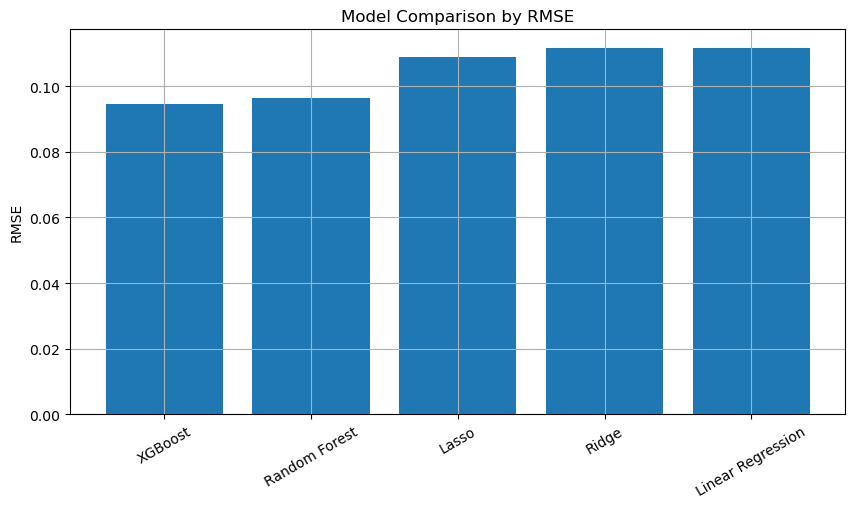

In [16]:
# ── RANDOM FOREST AND XGBOOST ────────────────────────────────────────────────
rf = RandomForestRegressor(
    n_estimators=40,
    max_depth=18,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
results.append(evaluate_model("Random Forest", rf, X_train, y_train, X_test, y_test))

if XGBOOST_AVAILABLE:
    xgb = XGBRegressor(
        n_estimators=80,
        max_depth=5,
        learning_rate=0.06,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    results.append(evaluate_model("XGBoost", xgb, X_train, y_train, X_test, y_test))
else:
    # Fallback keeps the notebook functional even in environments without xgboost.
    hgb = HistGradientBoostingRegressor(
        max_iter=260,
        learning_rate=0.06,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    )
    results.append(evaluate_model("HistGradientBoosting fallback", hgb, X_train, y_train, X_test, y_test))

metrics = pd.DataFrame([{k: v for k, v in r.items() if k not in ["predictions", "estimator"]} for r in results])
metrics = metrics.sort_values("RMSE")
display(metrics)

fig, ax = plt.subplots()
ax.bar(metrics["model"], metrics["RMSE"])
ax.set_title("Model Comparison by RMSE")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=30)
plt.show()

---
## Section 10 — Hyperparameter Optimization

Hyperparameter optimization searches model settings that are not learned directly from data, such as tree depth or learning rate. To respect time order, this notebook uses `TimeSeriesSplit` on the training set instead of random folds.

Reference: scikit-learn model selection documentation, https://scikit-learn.org/stable/modules/grid_search.html

In [17]:
# ── HYPERPARAMETER SEARCH ────────────────────────────────────────────────────
# To keep runtime reasonable, the search space is intentionally compact.
# For a final GitHub version, increase n_iter if computational resources allow.

tscv = TimeSeriesSplit(n_splits=2)

rf_param_dist = {
    "n_estimators": [40, 60, 80],
    "max_depth": [10, 14, 18, None],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", 0.7, 1.0]
}

# Optional speed control: tune on a deterministic subset of the training data.
tune_rows = min(10000, len(X_train))
X_tune = X_train.sample(tune_rows, random_state=RANDOM_STATE)
y_tune = y_train.loc[X_tune.index]

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE),
    param_distributions=rf_param_dist,
    n_iter=3,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)

rf_search.fit(X_tune, y_tune)
print("Best RF parameters:", rf_search.best_params_)

best_rf_result = evaluate_model("Tuned Random Forest", rf_search.best_estimator_, X_train, y_train, X_test, y_test)
results.append(best_rf_result)

if XGBOOST_AVAILABLE:
    xgb_param_dist = {
        "n_estimators": [60, 80, 100],
        "max_depth": [3, 4, 5, 6],
        "learning_rate": [0.03, 0.06, 0.1],
        "subsample": [0.75, 0.9, 1.0],
        "colsample_bytree": [0.75, 0.9, 1.0]
    }
    xgb_search = RandomizedSearchCV(
        estimator=XGBRegressor(objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1),
        param_distributions=xgb_param_dist,
        n_iter=3,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0
    )
    xgb_search.fit(X_tune, y_tune)
    print("Best XGB parameters:", xgb_search.best_params_)
    results.append(evaluate_model("Tuned XGBoost", xgb_search.best_estimator_, X_train, y_train, X_test, y_test))

metrics = pd.DataFrame([{k: v for k, v in r.items() if k not in ["predictions", "estimator"]} for r in results]).sort_values("RMSE")
display(metrics)

Best RF parameters: {'n_estimators': 80, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 18}
Best XGB parameters: {'subsample': 0.9, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.75}


,model,MAE,RMSE,R2
6,Tuned XGBoost,0.060843,0.090223,0.693757
4,XGBoost,0.066168,0.094425,0.664571
3,Random Forest,0.067041,0.096439,0.650110
5,Tuned Random Forest,0.067732,0.097757,0.640477
2,Lasso,0.089263,0.108980,0.553186
1,Ridge,0.092057,0.111702,0.530595
0,Linear Regression,0.092059,0.111703,0.530582


---
## Section 11 — Model Diagnostics

Diagnostics compare predicted versus observed snowfall and residual patterns. A useful regression model should have predictions close to the 1:1 line and residuals without strong systematic structure.

Best model: Tuned XGBoost
model    Tuned XGBoost
MAE           0.060843
RMSE          0.090223
R2            0.693757
Name: 6, dtype: object


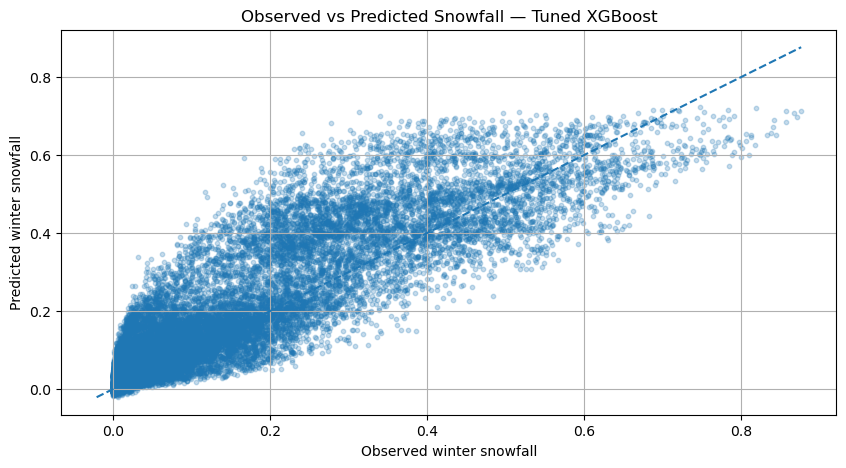

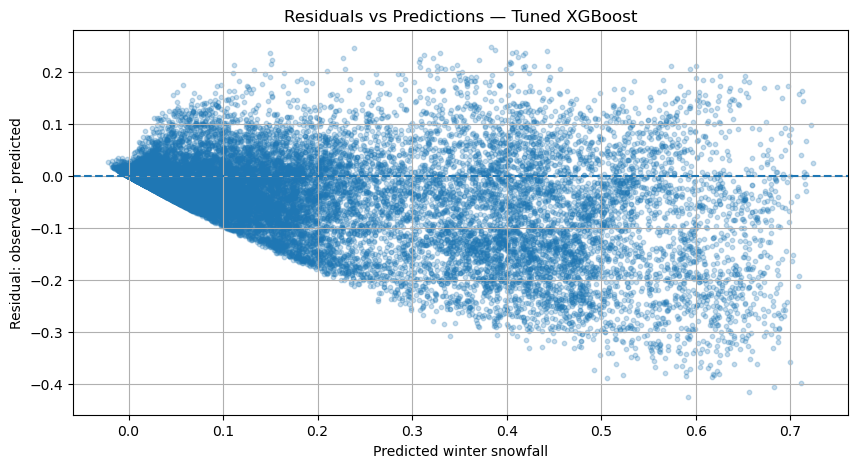

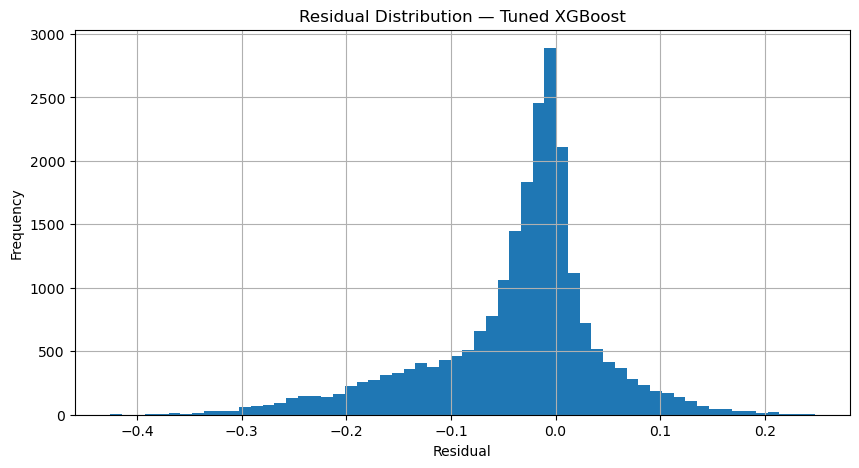

In [18]:
# ── MODEL DIAGNOSTICS ────────────────────────────────────────────────────────
best_row = metrics.iloc[0]
best_name = best_row["model"]
best_result = next(r for r in results if r["model"] == best_name)
best_model = best_result["estimator"]
best_pred = best_result["predictions"]
residuals = y_test.values - best_pred

print("Best model:", best_name)
print(best_row)

fig, ax = plt.subplots()
ax.scatter(y_test, best_pred, alpha=0.25, s=10)
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
ax.plot(lims, lims, linestyle="--")
ax.set_title(f"Observed vs Predicted Snowfall — {best_name}")
ax.set_xlabel("Observed winter snowfall")
ax.set_ylabel("Predicted winter snowfall")
plt.show()

fig, ax = plt.subplots()
ax.scatter(best_pred, residuals, alpha=0.25, s=10)
ax.axhline(0, linestyle="--")
ax.set_title(f"Residuals vs Predictions — {best_name}")
ax.set_xlabel("Predicted winter snowfall")
ax.set_ylabel("Residual: observed - predicted")
plt.show()

fig, ax = plt.subplots()
ax.hist(residuals, bins=60)
ax.set_title(f"Residual Distribution — {best_name}")
ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")
plt.show()

---
## Section 12 — Explainability

### 12.1 Feature Importance

Feature importance helps answer which predictors contribute most to the trained model. Tree impurity importance is quick, while permutation importance is more model-agnostic because it measures performance loss after shuffling each feature. Reference: https://scikit-learn.org/stable/modules/permutation_importance.html

### 12.2 SHAP Analysis

SHAP values explain a prediction by assigning each feature a contribution based on Shapley values from cooperative game theory. TreeExplainer is designed for tree ensembles. Reference: https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html

,feature,importance
10,autumn_temp_mean,0.615596
5,nov_temp,0.246855
14,elevation_x_precip,0.027979
2,year,0.018707
1,lon,0.014292
0,lat,0.013485
11,autumn_precip_total,0.010775
8,nov_precip,0.009460
6,sep_precip,0.005694
7,oct_precip,0.005386


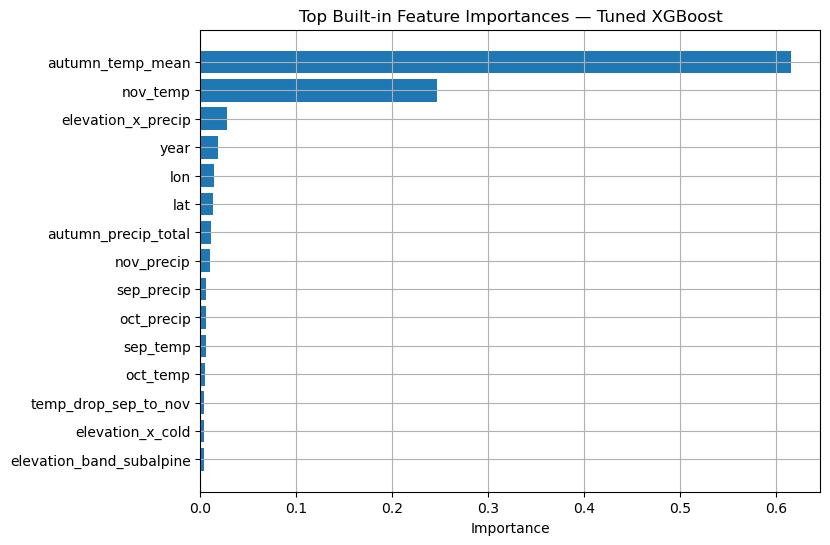

,feature,importance_mean,importance_std
10,autumn_temp_mean,0.042761,0.001156
5,nov_temp,0.017894,0.001198
1,lon,0.015067,0.002313
0,lat,0.008526,0.000307
9,elevation,0.003766,0.000321
14,elevation_x_precip,0.001313,0.000241
15,elevation_x_cold,0.000538,0.000157
13,precip_temp_interaction,0.000149,0.000141
16,elevation_band_foothill,0.000019,0.000008
2,year,0.000000,0.000000


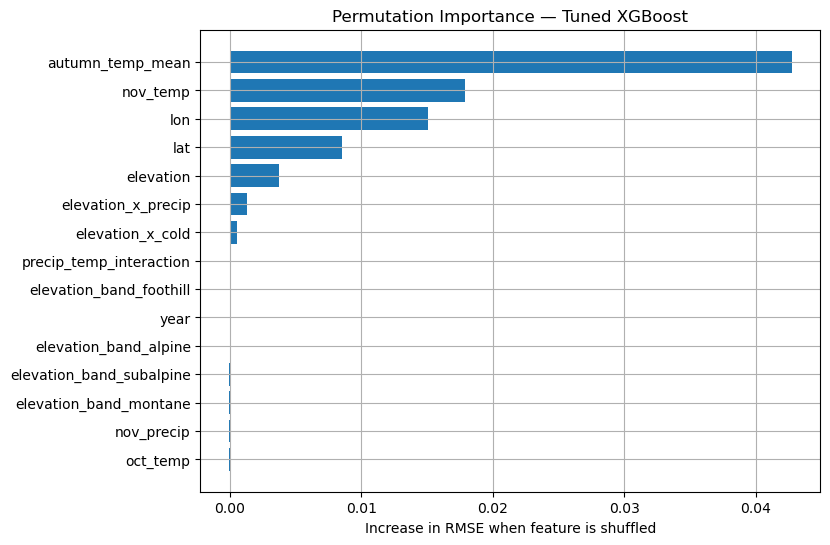

In [19]:
# ── 12.1 FEATURE IMPORTANCE ──────────────────────────────────────────────────
# Built-in feature importances are available for tree-based models.
if hasattr(best_model, "feature_importances_"):
    imp = pd.DataFrame({"feature": FEATURES, "importance": best_model.feature_importances_})
else:
    # Pipelines and linear models do not expose tree importances.
    imp = None

if imp is not None:
    imp = imp.sort_values("importance", ascending=False).head(15)
    display(imp)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(imp["feature"][::-1], imp["importance"][::-1])
    ax.set_title(f"Top Built-in Feature Importances — {best_name}")
    ax.set_xlabel("Importance")
    plt.show()

# Permutation importance on a sample for runtime control.
sample_size = min(1000, len(X_test))
X_perm = X_test.sample(sample_size, random_state=RANDOM_STATE)
y_perm = y_test.loc[X_perm.index]
perm = permutation_importance(
    best_model, X_perm, y_perm,
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring="neg_root_mean_squared_error"
)
perm_df = pd.DataFrame({
    "feature": FEATURES,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False).head(15)

display(perm_df)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(perm_df["feature"][::-1], perm_df["importance_mean"][::-1])
ax.set_title(f"Permutation Importance — {best_name}")
ax.set_xlabel("Increase in RMSE when feature is shuffled")
plt.show()

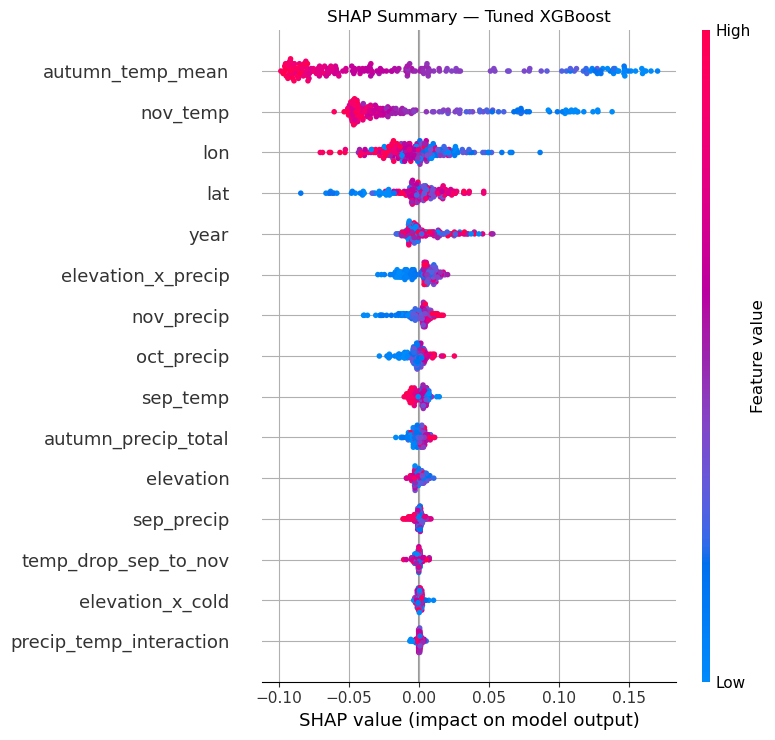

In [20]:
# ── 12.2 SHAP ANALYSIS ───────────────────────────────────────────────────────
# SHAP can be computationally expensive, so we explain a small test sample.
if SHAP_AVAILABLE and hasattr(best_model, "feature_importances_"):
    X_shap = X_test.sample(min(200, len(X_test)), random_state=RANDOM_STATE)
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_shap)
    shap.summary_plot(shap_values, X_shap, show=False, max_display=15)
    plt.title(f"SHAP Summary — {best_name}")
    plt.tight_layout()
    plt.show()
else:
    print("SHAP plot skipped because SHAP is unavailable or the best model is not a tree ensemble.")

---
## Section 13 — Limitations

1. **Reanalysis is not direct observation.** ERA5-Land is physically modeled and observation-constrained, but it is not the same as station measurement.
2. **Monthly predictors are simplified.** Daily extremes, snowline events, and storm tracks are not explicitly modeled.
3. **Spatial autocorrelation exists.** Neighboring grid cells are not fully independent.
4. **Autumn-to-winter prediction is intentionally limited.** The model does not use winter temperature or winter precipitation as predictors because the research question asks whether autumn conditions can predict future snowfall.
5. **Topography is simplified.** Elevation is included, but slope, aspect, wind exposure, and valley shielding are not.
6. **Climate change non-stationarity.** Relationships learned from 2000–2020 may shift in warmer future climates.

---
## Section 14 — References

### Climate and data sources

1. Copernicus Climate Data Store. **ERA5-Land hourly data from 1950 to present.** https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land  
2. ECMWF. **ERA5-Land.** https://www.ecmwf.int/en/era5-land  
3. Muñoz-Sabater, J. et al. (2021). **ERA5-Land: a state-of-the-art global reanalysis dataset for land applications.** *Earth System Science Data*, 13, 4349–4383. https://essd.copernicus.org/articles/13/4349/2021/  
4. Napoli, A. et al. (2019). **Variability of orographic enhancement of precipitation in the Alpine region.** https://pmc.ncbi.nlm.nih.gov/articles/PMC6746858/  
5. Copernicus Climate Change Service. **Climate reanalysis overview.** https://climate.copernicus.eu/climate-reanalysis  

### Machine learning and statistical methods

6. scikit-learn. **LinearRegression.** https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html  
7. scikit-learn. **Ridge.** https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html  
8. scikit-learn. **Lasso.** https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html  
9. scikit-learn. **RandomForestRegressor.** https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html  
10. scikit-learn. **Permutation feature importance.** https://scikit-learn.org/stable/modules/permutation_importance.html  
11. scikit-learn. **Model evaluation: regression metrics.** https://scikit-learn.org/stable/modules/model_evaluation.html  
12. scikit-learn. **Hyperparameter search / GridSearchCV and RandomizedSearchCV.** https://scikit-learn.org/stable/modules/grid_search.html  
13. XGBoost developers. **XGBoost documentation.** https://xgboost.readthedocs.io/en/stable/  
14. XGBoost developers. **XGBoost parameters.** https://xgboost.readthedocs.io/en/stable/parameter.html  
15. SHAP documentation. **TreeExplainer.** https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html  
16. SHAP documentation. **Introduction to explainable AI with Shapley values.** https://shap.readthedocs.io/en/latest/example_notebooks/overviews/An%20introduction%20to%20explainable%20AI%20with%20Shapley%20values.html

### Project guideline alignment

The notebook is designed to satisfy the project requirements by providing: a clear problem formulation, mathematical explanation, documented code, several methods, data validation, visualizations, metrics, and cited sources.